# Deep Probabilisic Models: BNN

Cristian D. Guarnizo PhD and Hernan F. García PhD

This session aims at understanding and implementing basic Bayesian Deep Learning models, as described in [Bayes by Backprop](https://arxiv.org/abs/1505.05424), and a short comparison with [Monte Carlo Dropout](  https://arxiv.org/abs/1506.02142).

![](https://github.com/charlesollion/dlexperiments/raw/master/6-Bayesian-DL/BDLworkflow.png)

**What this is not about:**

- answering questions about a dataset
- Deep Bayesian Learning: *What*, *Why*

**What this is about:**

- Deep Bayesian Learning: *How*
- trying to stick to classic deep learning frameworks and practice
- understanding basic building blocks

The notebook itself is inspired from [Khalid Salama's Keras tutorial on Bayesian Deep Learning](https://keras.io/examples/keras_recipes/bayesian_neural_networks/), and takes several graphs from the excellent paper [Hands-on Bayesian Neural Networks - a Tutorial for Deep Learning Users
](https://arxiv.org/abs/2007.06823).

## Installation

In this notebook, basic probabilistic Bayesian neural networks are built, with a focus on practical implementation. We consider both of the most populat deep learning frameworks: Tensorflow (and Keras) or Pytorch. Feel free to use your favorite.

For Tensorflow (2.3 or higher), [TensorFlow Probability](https://www.tensorflow.org/probability) library is used which is compatible with Keras API. If you're outside of Colab, you may install it with pip:

```python
pip install tensorflow-probability
```

For pytorch, the built-in `torch.distributions` will be used:

```python
pip install pytorch
```

Outside of Colab, you can install [TensorFlow Datasets](https://www.tensorflow.org/datasets/catalog/wine_quality) using the following command:

```python
pip install tensorflow-datasets
```

## The dataset

We use the [Wine Quality](https://archive.ics.uci.edu/ml/datasets/wine+quality)
dataset, which is available in the .
We use the red wine subset, which contains 4,898 examples.
The dataset has 11 numerical physicochemical features of the wine, and the task
is to predict the wine quality, which is a score between 0 and 10.

While the experts gave integer scores, we will first consider them as continuous values between 0 and 10 and treat this as a regression task, for simplicity and easy interpretation of confidence intervals.

We could consider instead consider a classification task, or the addition of an observation noise, or many different things here, but it's not the point of this session.

In [145]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import tensorflow_probability as tfp

# Benefits of Keras/Tensorflow
# + no management of CPU/GPU
# + once the model is defined, very easy to train
# - quite verbose code to define models
# - a lot is hidden, difficult to track bugs and what's really going on

In [146]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Benefits of Pytorch
# + easier to debug and to control
# - manage GPU/CPU (but it's easy)

### Create training and evaluation datasets

In [147]:
FEATURE_NAMES = [
    "fixed acidity", "volatile acidity", "citric acid",
    "residual sugar", "chlorides", "free sulfur dioxide",
    "total sulfur dioxide", "density", "pH",
    "sulphates", "alcohol",
]

def process_data(x,y):
    x_transform = tf.stack([tf.cast(x[f], tf.float32) for f in FEATURE_NAMES], 0)
    return x_transform, tf.cast(y, tf.float32) # cast y (integer) as a float

def get_train_and_test_splits(train_size, batch_size=1):
    dataset = (
        tfds.load(name="wine_quality", as_supervised=True, split="train")
        .map(process_data)
        .cache()
    )
    # We shuffle with a buffer the same size as the dataset.
    train_dataset = dataset.take(train_size).shuffle(buffer_size=train_size).batch(batch_size)
    test_dataset = dataset.skip(train_size).batch(batch_size)

    return train_dataset, test_dataset

Let's split the wine dataset into training and test sets, with 85% and 15% of
the examples, respectively.

In [148]:
dataset_size = 4898
batch_size = 256
train_size = int(dataset_size * 0.85)
M = int(train_size / batch_size)
train_dataset, test_dataset = get_train_and_test_splits(train_size, batch_size)

### Pytorch conversion

We can transform the tensorflow dataset into a pytorch one. The following is a simple way to do so (it is not a very good practice, but is doable as the dataset is small).

In [149]:
dataset = tfds.load(name="wine_quality", as_supervised=True, split="train").map(process_data)

def process_data_torch(x,y):
    x_transform = torch.tensor(x.numpy(), device=device)
    y_transform = torch.tensor(y.numpy(), device=device)
    return (x_transform, y_transform)

data_train = list(map(lambda x: process_data_torch(*x), dataset.take(train_size)))
data_test = list(map(lambda x: process_data_torch(*x), dataset.skip(train_size)))
torch_trainloader = torch.utils.data.DataLoader(data_train, batch_size=batch_size)
torch_testloader = torch.utils.data.DataLoader(data_test, batch_size=batch_size)

## 1) Standard neural network

We create a standard deterministic neural network model as a baseline.

<img src="https://raw.githubusercontent.com/charlesollion/dlexperiments/master/6-Bayesian-DL/stochasticNN.png" width="400" height="200">

### Tensorflow / Keras version

In [51]:
def create_baseline_model(input_dim, hidden_dim):
    inputs = layers.Input(shape=(input_dim,))

    # Hidden layer with deterministic weights using a Dense layer,
    # and non linear activation function
    features = layers.Dense(hidden_dim, activation="sigmoid")(inputs)

    # The output is deterministic: a single point estimate.
    outputs = layers.Dense(units=1)(features)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [52]:
learning_rate = 0.001

def run_experiment(model, loss, epochs, train_dataset, test_dataset):
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=learning_rate),
        loss=loss,
        metrics=[keras.metrics.RootMeanSquaredError()],
    )

    model.fit(train_dataset, epochs=num_epochs, validation_data=test_dataset)
    _, rmse = model.evaluate(train_dataset, verbose=0)
    print(f"Train RMSE: {round(rmse, 3)}")

    _, rmse = model.evaluate(test_dataset, verbose=0)
    print(f"Test RMSE: {round(rmse, 3)}")

In [53]:
baseline_model = create_baseline_model(11, 32)
baseline_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
num_epochs = 50
mse_loss = keras.losses.MeanSquaredError()
run_experiment(baseline_model, mse_loss, num_epochs, train_dataset, test_dataset)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 35.4458 - root_mean_squared_error: 5.9483 - val_loss: 24.8262 - val_root_mean_squared_error: 4.9826
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.6084 - root_mean_squared_error: 4.8579 - val_loss: 19.1796 - val_root_mean_squared_error: 4.3795
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.5541 - root_mean_squared_error: 4.3067 - val_loss: 15.1058 - val_root_mean_squared_error: 3.8866
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.4463 - root_mean_squared_error: 3.8000 - val_loss: 11.6538 - val_root_mean_squared_error: 3.4138
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.1102 - root_mean_squared_error: 3.3324 - val_loss: 8.5214 - val_root_mean_squared_error: 2.9191
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7782 - root_mean_squared_error: 2.7875 - val_loss: 5.3977 - val_root_mean_squared_error: 2.3233
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

We take a sample from the test set use the model to obtain predictions for them.
Note that since the baseline model is deterministic, we get a single a
*point estimate* prediction for each test example, with no information about the
uncertainty of the model nor the prediction.

In [55]:
samples = 10
examples, targets = list(test_dataset.unbatch().shuffle(batch_size * 10).batch(samples))[0]

predicted = baseline_model(examples).numpy()
for idx in range(samples):
    print(f"Predicted: {round(float(predicted[idx][0]), 1)} - Actual: {targets[idx]}")

Predicted: 5.3 - Actual: 5.0
Predicted: 5.5 - Actual: 4.0
Predicted: 6.3 - Actual: 7.0
Predicted: 5.7 - Actual: 6.0
Predicted: 5.8 - Actual: 7.0
Predicted: 5.8 - Actual: 7.0
Predicted: 5.9 - Actual: 5.0
Predicted: 6.2 - Actual: 5.0
Predicted: 6.2 - Actual: 6.0
Predicted: 5.7 - Actual: 5.0


### Pytorch version

In [56]:
class BaselineTorchModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(BaselineTorchModel, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, hidden_dim)
        self.out_layer = nn.Linear(hidden_dim, 1)
        self.act = torch.sigmoid

    def forward(self, inputs):
        h = self.hidden_layer(inputs)
        h = self.act(h)
        output = self.out_layer(h)

        # we add a dummy output, a placeholder for future experiments
        return output, None

In [57]:
from tqdm import tqdm

def run_experiment_torch(model, loss, num_epochs, train_dataloader, test_dataloader):
    optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    model.train()
    for e in tqdm(range(num_epochs)):
        for x, y in train_dataloader:
            optimizer.zero_grad()
            loss_value = loss(model(x), y)
            loss_value.backward()
            optimizer.step()

    model.eval()
    errors = []
    for x,y in test_dataloader:
        yhat, _ = model(x)
        errors.append(((torch.squeeze(yhat) - y)**2).detach().cpu().numpy())

    rmse = np.sqrt(np.mean(np.concatenate(errors, axis=None)))
    print(f"Test RMSE: {round(rmse, 3)}")

In [58]:
baseline_torch_model = BaselineTorchModel(11, 32).to(device)
baseline_torch_model

BaselineTorchModel(
  (hidden_layer): Linear(in_features=11, out_features=32, bias=True)
  (out_layer): Linear(in_features=32, out_features=1, bias=True)
)

In [59]:
[p.numel() for p in baseline_torch_model.parameters()]

[352, 32, 32, 1]

In [60]:
def simple_mse_loss(model_outputs, y_true):
    yhat, _ = model_outputs
    yhat = torch.squeeze(yhat)
    return torch.nn.MSELoss()(yhat, y_true)

run_experiment_torch(baseline_torch_model,
                     simple_mse_loss,
                     50, torch_trainloader, torch_testloader)

100%|██████████| 50/50 [00:01<00:00, 34.38it/s]

Test RMSE: 0.8059999942779541


In [61]:
samples = 10
examples_torch, targets_torch = next(iter(torch_testloader))
predicted, _ = baseline_torch_model(examples_torch[:samples])
predicted = predicted.detach().cpu().numpy()
for idx in range(samples):
    print(f"Predicted: {round(float(predicted[idx][0]), 1)} - Actual: {targets_torch[idx]}")

Predicted: 6.3 - Actual: 7.0
Predicted: 5.9 - Actual: 5.0
Predicted: 5.7 - Actual: 7.0
Predicted: 5.6 - Actual: 6.0
Predicted: 6.2 - Actual: 6.0
Predicted: 6.0 - Actual: 5.0
Predicted: 5.7 - Actual: 5.0
Predicted: 5.9 - Actual: 6.0
Predicted: 5.8 - Actual: 6.0
Predicted: 6.4 - Actual: 7.0


## 2) A simple Bayesian Neural Network

Our objective is to build a single layer Bayesian Neural Network using Tensorflow or Pytorch.

<img src="https://raw.githubusercontent.com/charlesollion/dlexperiments/master/6-Bayesian-DL/stochasticNN.png" width="400" height="200">

We define a unit Gaussian prior, and a diagonal covariance multivariate Gaussian posterior.

From the [Bayes by Backprop](https://arxiv.org/abs/1505.05424) paper, we have the following algorithm:

1. Sample $\epsilon ∼ N(0, I)$.
2. Let $w = µ + log(1 + exp(ρ)) ◦ \epsilon$.
3. Let $θ = (µ, ρ)$.
4. Let $f(w, θ) = log q(w|θ) − log P(w)P(D|w)$.
5. Compute gradients with respect to everything

Note that the $∂f(w,θ) ∂w$ term of the gradients are exactly the gradients found by the usual backpropagation algorithm on a neural network. Thus, remarkably, to learn both the mean and the standard deviation we must simply calculate the usual gradients found by backpropagation.

When working on $M$ mini-batches $D_i$ of data, the authors propose the (equivalent) following cost function to differentiate:

$$f(w, θ, D_i) = − log P(D_i|w) + \frac{1}{M} KL[q(w|θ) || P(w)] $$

This is convenient as the cost function is seperated in two terms, one which corresponds to the standard mse loss as before, and the other a regularization term: the KL divergence between the posterior q and the prior. Note that there is a weight ($\frac{1}{M}$) which can be chosen with different schemes.

### Tensorflow / Keras version

We will first consider having a single layer that has distribution over the weights. We can derive the Keras Layer class to build it:

In [62]:
from tensorflow_probability.python.distributions import kullback_leibler
from tensorflow_probability import distributions as tfd

class LinearVariational(tf.keras.layers.Layer):
    def __init__(self,
               units,
               kl_weight=1.0,
               activation=None):
        super(LinearVariational, self).__init__()
        self.units = int(units)
        self.kl_weight = kl_weight
        self.activation = tf.keras.activations.get(activation)

    def _make_prior(self, n):
        return tfp.distributions.MultivariateNormalDiag(loc=tf.zeros(n),
                                                 scale_diag=tf.ones(n))

    def _make_posterior(self, dim):
        # A bit of boilerplate to define Keras Layers with the parameters
        # Instead of using tf.keras.models.Sequential, we define the layers separately
        # and then combine them in the call method.
        self.variable_layer = tfp.layers.VariableLayer(
              shape=[dim, 2], #first is for mu, second for rho
              dtype=tf.float64,
              initializer=tfp.layers.BlockwiseInitializer([
                  'zeros', # initialize mu to 0
                  tf.keras.initializers.Constant(np.log(np.expm1(1.))), # initialize rho s.t. softplus(rho)=1
              ], sizes=[1, 1]))
        self.distribution_lambda = tfp.layers.DistributionLambda(lambda t: tfd.MultivariateNormalDiag(loc=t[..., 0],
                                                                             scale_diag=tf.math.softplus(t[..., 1])))


    def build(self, input_shape):
        input_shape = tf.TensorShape(input_shape)
        last_dim = tf.compat.dimension_value(input_shape[-1])
        self._make_posterior(last_dim * self.units) # Call _make_posterior to initialize the layers
        self.prior = self._make_prior(last_dim * self.units)
        self.built = True

    def call(self, inputs):
        # Instead of calling the Sequential model, we call the layers directly.
        t = self.variable_layer(0.)
        q = self.distribution_lambda(t)
        p = self.prior

        kl = kullback_leibler.kl_divergence(q, p)
        self.add_loss(tf.reduce_sum(kl) * self.kl_weight)

        w = q.sample() # differentiable because MultivariateNormalDiag
                       # implicitly uses reparametrization trick

        # Otherwise, we could have coded the reparametrization trick
        # directly from mu and rho as follows:
        # epsilon = tf.random.normal(mu.shape, 0, 1, tf.float32)
        # w = mu + tf.math.softplus(rho) * epsilon

        w = tf.reshape(w, shape=[-1, self.units])
        outputs = tf.matmul(inputs, w)

        if self.activation is not None:
            outputs = self.activation(outputs)

        return outputs

In [63]:
def create_bnn_model(input_dim, hidden_dim, kl_weight=1.):
    inputs = layers.Input(shape=(input_dim,))
    features = layers.BatchNormalization()(inputs)

    # Create our stochastic layer which has a distribution over weights
    z = LinearVariational(hidden_dim, kl_weight=kl_weight)(features)

    # The output is deterministic: a single point estimate.
    output = layers.Dense(units=1)(z)
    model = keras.Model(inputs=inputs, outputs=output)
    return model


In [64]:
bnn_model_small = create_bnn_model(11, 32, kl_weight = 1. / train_size)
bnn_model_small.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 11)             │            44 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_variational_1            │ (None, 32)             │             0 │
│ (LinearVariational)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77 (308.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 22 (88.00 B)

Note that there are now more trainable parameters, even though we don't have a bias for the hidden layer.

The KL weight, the authors of the original paper propose either $\frac{1}{M}$ with $M$ the number of minibatches in the dataset for each epoch, of $\frac{2^{M-i}}{2^M-1}$ where $i$ is the batch index. In practice here it was chosen as an hyperparameter.

In [65]:
num_epochs = 200
run_experiment(bnn_model_small, mse_loss, num_epochs, train_dataset, test_dataset)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - loss: 48.6665 - root_mean_squared_error: 6.9754 - val_loss: 33.1630 - val_root_mean_squared_error: 5.7587
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 50.6250 - root_mean_squared_error: 7.1139 - val_loss: 23.9773 - val_root_mean_squared_error: 4.8967
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45.4762 - root_mean_squared_error: 6.7429 - val_loss: 128.3402 - val_root_mean_squared_error: 11.3287
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 43.5395 - root_mean_squared_error: 6.5972 - val_loss: 182.1687 - val_root_mean_squared_error: 13.4970
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 46.2728 - root_mean_squared_error: 6.8015 - val_loss: 64.4804 - val_root_mean_squared_error: 8.0300
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 43.1112 - root_mean_squared_error: 6.5658 - val_loss: 17.1511 - val_root_mean_squared_error: 4.1414
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 

In [66]:
def compute_predictions(model, iterations=100):
    predicted = []
    for _ in range(iterations):
        predicted.append(model(examples).numpy())
    predicted = np.concatenate(predicted, axis=1)
    return predicted

def display_predictions(predictions, targets):
    prediction_mean = np.mean(predictions, axis=1).tolist()
    prediction_min = np.min(predictions, axis=1).tolist()
    prediction_max = np.max(predictions, axis=1).tolist()
    prediction_range = (np.max(predictions, axis=1) - np.min(predictions, axis=1)).tolist()

    for idx in range(samples):
        print(
            f"Predictions mean: {round(prediction_mean[idx], 2)}, "
            f"min: {round(prediction_min[idx], 2)}, "
            f"max: {round(prediction_max[idx], 2)}, "
            f"range: {round(prediction_range[idx], 2)} - "
            f"Actual: {targets[idx]}"
        )

predictions = compute_predictions(bnn_model_small)
display_predictions(predictions, targets)

Predictions mean: 3.4, min: 3.08, max: 3.64, range: 0.56 - Actual: 5.0
Predictions mean: 3.41, min: 3.18, max: 3.72, range: 0.54 - Actual: 4.0
Predictions mean: 3.4, min: 3.12, max: 3.64, range: 0.52 - Actual: 7.0
Predictions mean: 3.41, min: 3.08, max: 3.63, range: 0.56 - Actual: 6.0
Predictions mean: 3.41, min: 3.31, max: 3.54, range: 0.23 - Actual: 7.0
Predictions mean: 3.4, min: 3.23, max: 3.54, range: 0.31 - Actual: 7.0
Predictions mean: 3.4, min: 3.29, max: 3.52, range: 0.23 - Actual: 5.0
Predictions mean: 3.4, min: 3.13, max: 3.65, range: 0.52 - Actual: 5.0
Predictions mean: 3.4, min: 3.19, max: 3.66, range: 0.47 - Actual: 6.0
Predictions mean: 3.4, min: 3.3, max: 3.51, range: 0.21 - Actual: 5.0


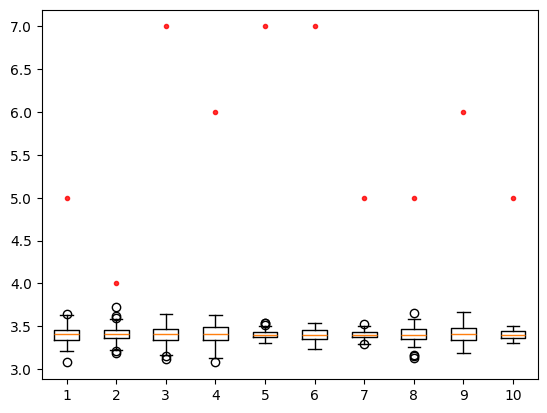

In [67]:
import matplotlib.pyplot as plt
plt.boxplot(predictions.T)
plt.plot(range(1,11), targets, 'r.', alpha=0.8);

### Pytorch version

In [68]:
class BnnTorch(nn.Module):
    def __init__(self, input_dim, hidden_dim, activation=None):
        super(BnnTorch, self).__init__()
        n = input_dim * hidden_dim
        self.mu = nn.Parameter(torch.zeros((n), dtype=torch.float32))
        self.rho  = nn.Parameter(torch.log(torch.expm1(torch.ones((n), dtype=torch.float32))))
        self.out_layer = nn.Linear(hidden_dim, 1)
        self.act = activation
        self.hidden_dim = hidden_dim
        self.prior = torch.distributions.Normal(loc=torch.zeros((n), device=device, dtype=torch.float32),
                                                scale=torch.ones((n), device=device, dtype=torch.float32))
        self.kl_func = torch.distributions.kl.kl_divergence
        self.batch_norm = torch.nn.BatchNorm1d(input_dim)


    def forward(self, inputs):
        inputs = self.batch_norm(inputs)
        q = torch.distributions.Normal(loc=self.mu,
                                       scale=torch.log(1.+torch.exp(self.rho)))

        kl = torch.sum(self.kl_func(q, self.prior))
        # we use q.rsample() which uses the reparametrization trick instead of
        # q.sample() which breaks the auto-differentation path
        w = q.rsample()
        w = w.reshape((-1, self.hidden_dim))
        h = inputs @ w
        if self.act is not None:
            h = self.act(h)
        output = self.out_layer(h)
        return output, kl

In [69]:
bnn_torch = BnnTorch(11, 32).to(device)
bnn_torch

BnnTorch(
  (out_layer): Linear(in_features=32, out_features=1, bias=True)
  (batch_norm): BatchNorm1d(11, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [70]:
kl_weight = 1. / train_size

def mse_kl_loss(model_outputs, y_true):
    yhat, kl = model_outputs
    yhat = torch.squeeze(yhat)
    mse = torch.nn.MSELoss()(yhat, y_true)
    return mse + kl * kl_weight

run_experiment_torch(bnn_torch,
                     mse_kl_loss,
                     200, torch_trainloader, torch_testloader)

100%|██████████| 200/200 [00:09<00:00, 21.62it/s]

Test RMSE: 0.8500000238418579


In [71]:
def compute_predictions_torch(model, iterations=100):
    predicted = []
    model.eval()
    for _ in range(iterations):
        preds, _ = model(examples_torch)
        predicted.append(preds.detach().cpu().numpy())
    predicted = np.concatenate(predicted, axis=1)
    return predicted

In [72]:
predictions = compute_predictions_torch(bnn_torch)
display_predictions(predictions, targets_torch)

Predictions mean: 6.14, min: 4.8, max: 7.03, range: 2.23 - Actual: 7.0
Predictions mean: 5.02, min: 4.24, max: 5.81, range: 1.57 - Actual: 5.0
Predictions mean: 5.3, min: 4.5, max: 6.22, range: 1.72 - Actual: 7.0
Predictions mean: 5.15, min: 4.37, max: 6.04, range: 1.67 - Actual: 6.0
Predictions mean: 5.41, min: 4.46, max: 6.13, range: 1.67 - Actual: 6.0
Predictions mean: 5.32, min: 4.41, max: 6.12, range: 1.71 - Actual: 5.0
Predictions mean: 5.24, min: 4.42, max: 6.23, range: 1.8 - Actual: 5.0
Predictions mean: 5.57, min: 4.65, max: 6.34, range: 1.69 - Actual: 6.0
Predictions mean: 5.37, min: 4.55, max: 6.21, range: 1.66 - Actual: 6.0
Predictions mean: 5.82, min: 4.7, max: 6.62, range: 1.92 - Actual: 7.0


In [73]:
targets_torch.shape

torch.Size([256])

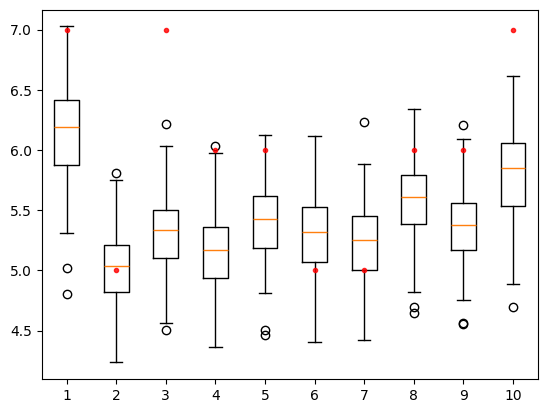

In [74]:
plt.boxplot(predictions[:10].T)
plt.plot(range(1,11), targets_torch[:10].cpu(), 'r.', alpha=0.8);

## 3) Full Bayesian neural network

con pytorch

In [153]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Parámetros de la posterior (media y varianza)
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.weight_log_var = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias_mu = nn.Parameter(torch.Tensor(out_features))
        self.bias_log_var = nn.Parameter(torch.Tensor(out_features))

        # Prior fijo N(0,1)
        self.register_buffer('weight_prior_loc', torch.zeros(out_features, in_features))
        self.register_buffer('weight_prior_scale', torch.ones(out_features, in_features))
        self.register_buffer('bias_prior_loc', torch.zeros(out_features))
        self.register_buffer('bias_prior_scale', torch.ones(out_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(self.weight_mu, 0, 0.1)
        nn.init.normal_(self.weight_log_var, -3, 0.1)
        nn.init.normal_(self.bias_mu, 0, 0.1)
        nn.init.normal_(self.bias_log_var, -3, 0.1)

    def forward(self, x):
        # Muestreo de pesos y bias
        weight_std = torch.exp(0.5 * self.weight_log_var)
        weight = self.weight_mu + weight_std * torch.randn_like(weight_std)

        bias_std = torch.exp(0.5 * self.bias_log_var)
        bias = self.bias_mu + bias_std * torch.randn_like(bias_std)

        # Cálculo de la KL
        q_weight = torch.distributions.Normal(self.weight_mu, weight_std)
        prior_weight = torch.distributions.Normal(
            self.weight_prior_loc, self.weight_prior_scale
        )
        kl_weight = torch.distributions.kl_divergence(q_weight, prior_weight).sum()

        q_bias = torch.distributions.Normal(self.bias_mu, bias_std)
        prior_bias = torch.distributions.Normal(
            self.bias_prior_loc, self.bias_prior_scale
        )
        kl_bias = torch.distributions.kl_divergence(q_bias, prior_bias).sum()

        total_kl = kl_weight + kl_bias

        return F.linear(x, weight, bias), total_kl

In [154]:
class BNN(nn.Module):
    def __init__(self, input_dim, hidden_units):
        super().__init__()
        self.batch_norm = nn.BatchNorm1d(input_dim)
        self.hidden_layers = nn.ModuleList()

        in_features = input_dim
        for units in hidden_units:
            self.hidden_layers.append(BayesianLinear(in_features, units))
            in_features = units

        self.output_layer = BayesianLinear(in_features, 1)

    def forward(self, x):
        kl_total = 0.0
        x = self.batch_norm(x)

        for layer in self.hidden_layers:
            x, kl = layer(x)
            kl_total += kl
            x = torch.sigmoid(x)  # Activación como en TensorFlow

        output, kl = self.output_layer(x)
        kl_total += kl

        return output.squeeze(), kl_total

In [155]:
def mse_kl_loss(model_outputs, y_true):
    y_pred, kl = model_outputs
    mse = F.mse_loss(y_pred, y_true)
    return mse + kl * kl_weight  # kl_weight definido previamente

def run_experiment_torch(model, loss_fn, epochs, train_loader, test_loader):
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            optimizer.zero_grad()
            y_pred, kl = model(x)
            loss = loss_fn((y_pred, kl), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validación
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, y in test_loader:
                y_pred, kl = model(x)
                test_loss += loss_fn((y_pred, kl), y).item()

        print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Test Loss: {test_loss/len(test_loader):.4f}")

In [156]:
# Configuración
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kl_weight = 1.0 / train_size  # Definido previamente

# Crear modelo
bnn_torch = BNN(input_dim=11, hidden_units=[8, 8]).to(device)

# Entrenar
run_experiment_torch(
    bnn_torch,
    mse_kl_loss,
    epochs=200,
    train_loader=torch_trainloader,
    test_loader=torch_testloader
)

# Predicción (similar a tu función compute_predictions_torch)
def compute_predictions_torch(model, examples, iterations=100):
    model.eval()
    predictions = []
    with torch.no_grad():
        for _ in range(iterations):
            pred, _ = model(examples)
            predictions.append(pred.cpu().numpy())
    return np.hstack(predictions)

Epoch 1: Train Loss: 39.8090, Test Loss: 39.8884
Epoch 2: Train Loss: 36.5283, Test Loss: 37.7584
Epoch 3: Train Loss: 37.7438, Test Loss: 30.7626
Epoch 4: Train Loss: 33.7386, Test Loss: 34.1643
Epoch 5: Train Loss: 32.7770, Test Loss: 31.2720
Epoch 6: Train Loss: 33.4466, Test Loss: 36.0792
Epoch 7: Train Loss: 32.9800, Test Loss: 31.0406
Epoch 8: Train Loss: 31.5505, Test Loss: 29.4898
Epoch 9: Train Loss: 29.7331, Test Loss: 29.0484
Epoch 10: Train Loss: 28.7717, Test Loss: 27.0451
Epoch 11: Train Loss: 26.8075, Test Loss: 25.1771
Epoch 12: Train Loss: 26.2433, Test Loss: 30.1624
Epoch 13: Train Loss: 26.8622, Test Loss: 19.9648
Epoch 14: Train Loss: 25.8968, Test Loss: 27.1309
Epoch 15: Train Loss: 26.6184, Test Loss: 27.4039
Epoch 16: Train Loss: 21.5131, Test Loss: 24.0566
Epoch 17: Train Loss: 23.8256, Test Loss: 21.0937
Epoch 18: Train Loss: 22.6290, Test Loss: 20.1415
Epoch 19: Train Loss: 20.7616, Test Loss: 24.6743
Epoch 20: Train Loss: 21.7040, Test Loss: 17.0104
Epoch 21:

## 4)Bayesian Neural Network parametrizing a distribution

So far, we have distributions over weights, but single point estimates for each input (once we sample these weights).

<img src="https://raw.githubusercontent.com/charlesollion/dlexperiments/master/6-Bayesian-DL/stochasticNN.png" width="400" height="200">

We can also model an output distribution, rather than a single point estimate. We will change the last layer to become a parametrization of a Gaussian as the output. This should be related to *aleatoric uncertainty*, irreducible noise in the data, capturing the stochastic nature of the process generating the data.

We then use the negative loglikelihood of this distribution as our loss function, instead of the MSE.

In [164]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as dist
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Parámetros de la posterior
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.weight_log_var = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias_mu = nn.Parameter(torch.Tensor(out_features))
        self.bias_log_var = nn.Parameter(torch.Tensor(out_features))

        # Prior fijo N(0,1)
        self.register_buffer('weight_prior_loc', torch.zeros(out_features, in_features))
        self.register_buffer('weight_prior_scale', torch.ones(out_features, in_features))
        self.register_buffer('bias_prior_loc', torch.zeros(out_features))
        self.register_buffer('bias_prior_scale', torch.ones(out_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(self.weight_mu, 0, 0.1)
        nn.init.normal_(self.weight_log_var, -3, 0.1)
        nn.init.normal_(self.bias_mu, 0, 0.1)
        nn.init.normal_(self.bias_log_var, -3, 0.1)

    def forward(self, x):
        # Muestreo de pesos
        weight_std = torch.exp(0.5 * self.weight_log_var)
        weight = self.weight_mu + weight_std * torch.randn_like(weight_std)

        bias_std = torch.exp(0.5 * self.bias_log_var)
        bias = self.bias_mu + bias_std * torch.randn_like(bias_std)

        # Cálculo de KL
        q_weight = dist.Normal(self.weight_mu, weight_std)
        prior_weight = dist.Normal(self.weight_prior_loc, self.weight_prior_scale)
        kl_weight = dist.kl_divergence(q_weight, prior_weight).sum()

        q_bias = dist.Normal(self.bias_mu, bias_std)
        prior_bias = dist.Normal(self.bias_prior_loc, self.bias_prior_scale)
        kl_bias = dist.kl_divergence(q_bias, prior_bias).sum()

        return F.linear(x, weight, bias), kl_weight + kl_bias

class ProbabilisticBNN(nn.Module):
    def __init__(self, input_dim, hidden_units):
        super().__init__()
        self.batch_norm = nn.BatchNorm1d(input_dim)

        self.hidden_layers = nn.ModuleList()
        in_features = input_dim
        for units in hidden_units:
            self.hidden_layers.append(BayesianLinear(in_features, units))
            in_features = units

        # Capa final para parámetros de la distribución
        self.output_layer = BayesianLinear(in_features, 2)

    def forward(self, x):
        kl_total = 0.0
        x = self.batch_norm(x)

        for layer in self.hidden_layers:
            x, kl = layer(x)
            kl_total += kl
            x = torch.sigmoid(x)

        # Obtener parámetros de la distribución
        x, kl = self.output_layer(x)
        kl_total += kl

        # Separar media y log varianza
        loc, log_scale = torch.chunk(x, 2, dim=-1)
        scale = F.softplus(log_scale) + 1e-6  # Asegurar escala positiva

        return dist.Normal(loc, scale), kl_total

def negative_loglikelihood(targets, estimated_distribution):
    return -estimated_distribution.log_prob(targets.squeeze()).mean()

def run_experiment(model, loss_fn, epochs, train_loader, test_loader, kl_weight):
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            distribution, kl = model(x)
            nll = loss_fn(y, distribution)
            loss = nll + kl * kl_weight

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validación
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                distribution, kl = model(x)
                test_loss += (loss_fn(y, distribution) + kl * kl_weight).item()

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"Test Loss: {test_loss/len(test_loader):.4f}\n")

# Configuración
input_dim = 11
hidden_units = [8, 8]
kl_weight = 1.0 / train_size  # Asegurar que está definido
epochs = 500

# Crear modelo
model = ProbabilisticBNN(input_dim, hidden_units).to(device)

# Ejecutar entrenamiento
run_experiment(
    model=model,
    loss_fn=negative_loglikelihood,
    epochs=epochs,
    train_loader=torch_trainloader,
    test_loader=torch_testloader,
    kl_weight=kl_weight
)

Epoch 1/500
Train Loss: 32.4698
Test Loss: 30.1548

Epoch 2/500
Train Loss: 29.2081
Test Loss: 29.5004

Epoch 3/500
Train Loss: 24.4902
Test Loss: 13.0375

Epoch 4/500
Train Loss: 17.9119
Test Loss: 31.7902

Epoch 5/500
Train Loss: 19.7958
Test Loss: 16.8517

Epoch 6/500
Train Loss: 20.3339
Test Loss: 18.7421

Epoch 7/500
Train Loss: 17.0874
Test Loss: 19.0228

Epoch 8/500
Train Loss: 12.0066
Test Loss: 10.5675

Epoch 9/500
Train Loss: 13.3504
Test Loss: 20.0330

Epoch 10/500
Train Loss: 14.9399
Test Loss: 9.2006

Epoch 11/500
Train Loss: 10.4928
Test Loss: 9.0324

Epoch 12/500
Train Loss: 9.9783
Test Loss: 6.1058

Epoch 13/500
Train Loss: 10.1900
Test Loss: 6.5553

Epoch 14/500
Train Loss: 8.3807
Test Loss: 5.4966

Epoch 15/500
Train Loss: 8.6765
Test Loss: 8.4815

Epoch 16/500
Train Loss: 8.6596
Test Loss: 8.9746

Epoch 17/500
Train Loss: 7.2539
Test Loss: 9.9831

Epoch 18/500
Train Loss: 6.4974
Test Loss: 6.0099

Epoch 19/500
Train Loss: 7.8729
Test Loss: 5.6593

Epoch 20/500
Train 

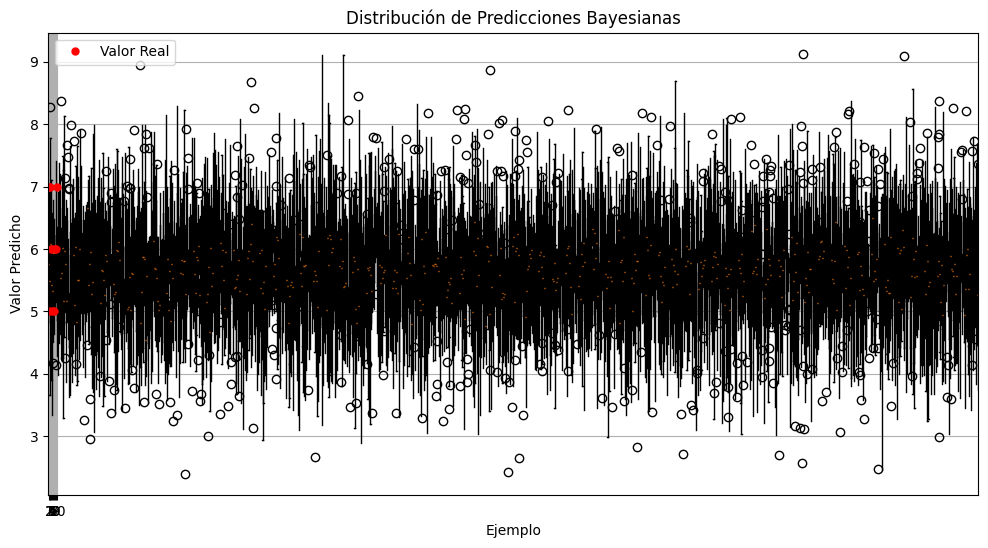

In [171]:
def compute_probabilistic_predictions(model, examples, n_samples=100):
    model.eval()
    with torch.no_grad():
        examples = examples.to(device)
        distribution, _ = model(examples)
        samples = distribution.sample((n_samples,))  # Shape: (n_samples, batch_size, 1)
        samples = samples.squeeze(-1)  # Eliminar la última dimensión (1)
    return samples.cpu().numpy()  # Shape: (n_samples, batch_size)

# Obtener un batch de ejemplos
examples_torch, targets_torch = next(iter(torch_testloader))
examples_torch = examples_torch.to(device)

# Generar predicciones (ahora con shape (1000, batch_size))
samples = compute_probabilistic_predictions(model, examples_torch, n_samples=1000)

# Visualizar
n_examples = 10
plt.figure(figsize=(12, 6))
plt.boxplot(samples[:, :n_examples].T)  # Shape: (n_examples, 1000)
plt.plot(range(1, n_examples+1), targets_torch[:n_examples].cpu().numpy(), 'r.', markersize=10, label='Valor Real')
plt.title('Distribución de Predicciones Bayesianas')
plt.xlabel('Ejemplo')
plt.ylabel('Valor Predicho')
plt.xticks(range(1, n_examples+1))
plt.legend()
plt.grid(True)
plt.show()

mejor view

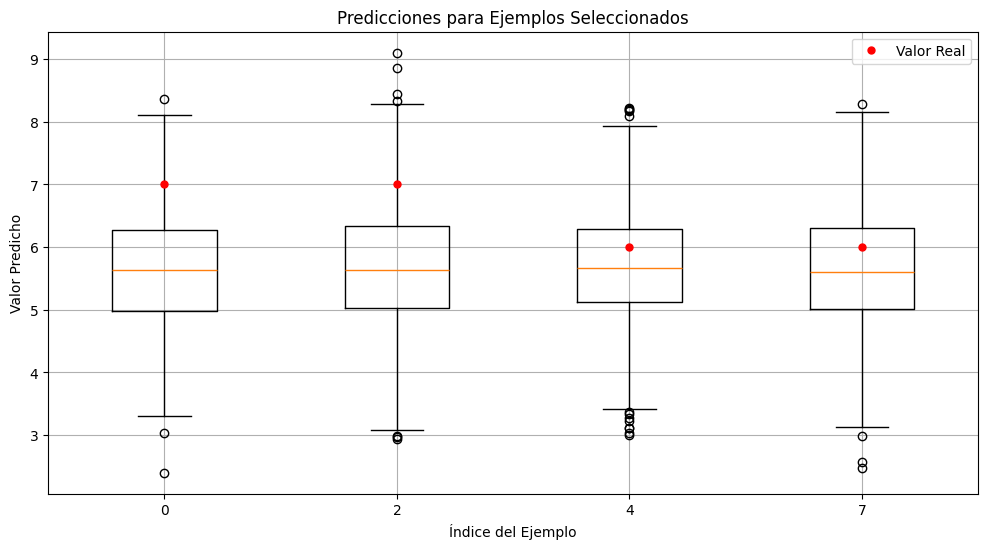

In [176]:
# Seleccionar índices de ejemplos (ej: [0, 2, 4, 7])
selected_indices = [0, 2, 4, 7]
n_examples = len(selected_indices)

# Obtener datos seleccionados (sin transponer)
selected_samples = samples[:, selected_indices]  # Shape: (n_samples, n_examples)
selected_targets = targets_torch[selected_indices].cpu().numpy()

# Crear el gráfico
plt.figure(figsize=(12, 6))

# Usar tick_labels en lugar de labels
plt.boxplot(
    selected_samples,
    tick_labels=selected_indices  # <--- ¡Corrección aquí!
)

plt.plot(
    range(1, n_examples + 1),
    selected_targets,
    'r.',
    markersize=10,
    label='Valor Real'
)

plt.title('Predicciones para Ejemplos Seleccionados')
plt.xlabel('Índice del Ejemplo')
plt.ylabel('Valor Predicho')
plt.legend()
plt.grid(True)
plt.show()

## 5) MC Dropout

We will now consider a simpler approach, as described in the [Monte Carlo Dropout](  https://arxiv.org/abs/1506.02142) paper. The implementation is extremely simple to people already familiar with dropout: we just need to keep dropout active at test time by forcing `training=True`.

In [178]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MCDropoutModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.2):
        super().__init__()
        self.dropout_rate = dropout_rate

        self.dense = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.sigmoid(self.dense(x))
        x = self.dropout(x)  # Dropout siempre activo (incluso en evaluación)
        x = self.output_layer(x)
        return x.squeeze()  # Para coincidir con la forma de los targets

def run_experiment_mcdropout(model, loss_fn, epochs, train_loader, test_loader):
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluación (sin dropout en test si se desea)
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                y_pred = model(x)
                test_loss += loss_fn(y_pred, y).item()

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"Test Loss: {test_loss/len(test_loader):.4f}\n")

In [179]:
# Configuración
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 11
hidden_dim = 32
dropout_rate = 0.2
epochs = 500

# Crear modelo
mc_model = MCDropoutModel(input_dim, hidden_dim, dropout_rate).to(device)

# Función de pérdida (solo MSE)
mse_loss = nn.MSELoss()

# Entrenar
run_experiment_mcdropout(
    model=mc_model,
    loss_fn=mse_loss,
    epochs=epochs,
    train_loader=torch_trainloader,
    test_loader=torch_testloader
)

Epoch 1/500
Train Loss: 28.9280
Test Loss: 26.1037

Epoch 2/500
Train Loss: 24.7355
Test Loss: 22.4382

Epoch 3/500
Train Loss: 21.1682
Test Loss: 18.4828

Epoch 4/500
Train Loss: 16.3009
Test Loss: 13.1669

Epoch 5/500
Train Loss: 11.8601
Test Loss: 9.8188

Epoch 6/500
Train Loss: 9.1082
Test Loss: 7.4903

Epoch 7/500
Train Loss: 6.8906
Test Loss: 5.4900

Epoch 8/500
Train Loss: 5.0705
Test Loss: 3.7812

Epoch 9/500
Train Loss: 3.5546
Test Loss: 2.6572

Epoch 10/500
Train Loss: 2.7052
Test Loss: 2.0397

Epoch 11/500
Train Loss: 2.2298
Test Loss: 1.6439

Epoch 12/500
Train Loss: 1.8833
Test Loss: 1.3695

Epoch 13/500
Train Loss: 1.6254
Test Loss: 1.1776

Epoch 14/500
Train Loss: 1.5271
Test Loss: 1.0417

Epoch 15/500
Train Loss: 1.2578
Test Loss: 0.7965

Epoch 16/500
Train Loss: 1.2125
Test Loss: 0.7902

Epoch 17/500
Train Loss: 1.2431
Test Loss: 0.7888

Epoch 18/500
Train Loss: 1.1749
Test Loss: 0.7873

Epoch 19/500
Train Loss: 1.1596
Test Loss: 0.7850

Epoch 20/500
Train Loss: 1.1725